#**Student Score Prediction System**

**Build a simple Machine Learning application that:**

**Loads the dataset.**

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def load_dataset():
    path = input("Enter dataset path: ")
    df = pd.read_csv(path)
    df["Avg_Score"] = df.iloc[:,4:8].mean(axis=1)
    return df

'''to make an application for this task , i need to ask the user for the target column
for the time being ,i dont have the "Avg_Score" , column thats why i am manually
creating it here.'''

'to make an application for this task , i need to ask the user for the target column\nfor the time being ,i dont have the "Avg_Score" , column thats why i am manually\ncreating it here.'

In [17]:
def display_dataset(df):
    print("\nDataset Preview")
    print(df.head())

    print("\nDataset Shape:", df.shape)

    print("\nColumns:")
    for i, col in enumerate(df.columns, start=1):
        print(f"{i}. {col}")


**Preprocesses the data.**

In [18]:
def preprocess_data(df):
    df = df.drop_duplicates()

    for col in df.columns:
        if df[col].dtype == "object":
            df[col].fillna(df[col].mode()[0], inplace=True)
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
        else:
            df[col].fillna(df[col].mean(), inplace=True)

    return df


def select_target(df):
    target = input("\nEnter the target column: ")

    while target not in df.columns:
        print("Invalid column name.")
        target = input("Enter the target column: ")

    return target


def split_data(df, target):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    return X_train, X_test, y_train, y_test


**Trains a Linear Regression model.**

In [19]:

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


**Predicts student average scores.**

In [20]:


def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, predictions)

    print("\nModel Evaluation")
    print("-" * 30)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R² Score : {r2:.2f}")

    return predictions


**Displays the model evaluation metrics.**

In [21]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, predictions)

    print("\nModel Evaluation")
    print("-" * 30)
    print(f"Mean Absolute Error (MAE) : {mae:.2f}")
    print(f"Mean Squared Error (MSE)  : {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
    print(f"R² Score : {r2:.2f}")

    return predictions

**Prints a comparison table of Actual vs Predicted scores.**

In [22]:

def show_predictions(y_test, predictions):
    comparison = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": predictions
    })

    print("\nActual vs Predicted")
    print(comparison)

In [27]:

if __name__ == "__main__":
    df = load_dataset()

    display_dataset(df)

    df = preprocess_data(df)

    target = select_target(df)

    X_train, X_test, y_train, y_test = split_data(df, target)

    model = train_model(X_train, y_train)

    predictions = evaluate_model(model, X_test, y_test)

    show_predictions(y_test, predictions)

    evaluate_model(model, X_test, y_test)

Enter dataset path: /content/student_performance.csv


/tmp/ipykernel_2190/427120497.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_2190/427120497.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi


Dataset Preview
  Student_ID         Name  Age Program  Python  Mathematics  Statistics  \
0       S001     Ali Khan   20      AI      85           78          92   
1       S002   Sara Ahmed   21      AI      72           75          70   
2       S003   Ahmed Raza   22      SE      90           88          91   
3       S004  Fatima Noor   20      DS      65           70          68   
4       S005    Usman Ali   21      AI      78           82          80   

   Machine_Learning  Attendance  Avg_Score  
0                88          95      85.75  
1                80          90      74.25  
2                93          96      90.50  
3                72          85      68.75  
4                76          88      79.00  

Dataset Shape: (20, 10)

Columns:
1. Student_ID
2. Name
3. Age
4. Program
5. Python
6. Mathematics
7. Statistics
8. Machine_Learning
9. Attendance
10. Avg_Score

Enter the target column: Avg_Score

Model Evaluation
------------------------------
Mean Absolute E

**Also Visualize the prediction results using a scatter plot showing Actual vs Predicted values.**

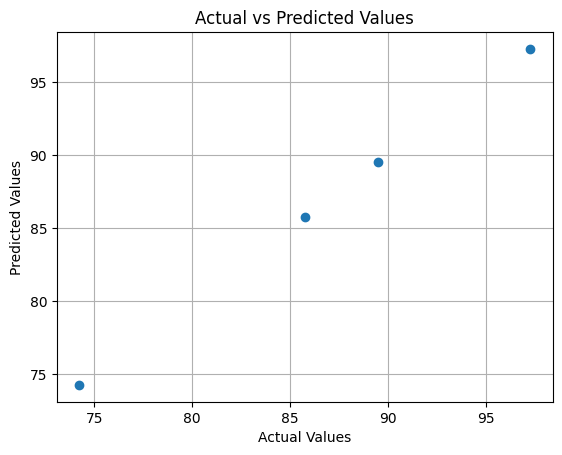

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()